# Assignment Sesi 18
Nama: Faraday Barr Fatahillah

**Instruksi**\
Anda bekerja sebagai data scientist di perusahaan telekomunikasi. Tim business intelligence minta Anda membangun model prediksi churn dan melaporkan model mana yang paling layak digunakan sebagai dasar kampanye retensi pelanggan.

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [152]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix, f1_score

**Task 1 — Persiapan Data**
1. Load dataset ke dataframe bernama df.
2. Periksa missing value dan tangani: kolom TotalCharges memiliki spasi kosong yang perlu dikonversi ke NaN lalu diisi dengan median.
3. Encode kolom target Churn (Yes=1, No=0).
4. Terapkan one-hot encoding untuk semua kolom kategorikal kecuali CustomerID.
5. Pisahkan fitur (X) dan target (y), lalu lakukan train-test split 80:20 dengan random_state=42.
6. Terapkan StandardScaler pada fitur numerik (tenure, MonthlyCharges, TotalCharges).

In [153]:
#Task 1.1
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv', na_values=["NA", "N/A", "null", "?", "-", " "])

df.isna().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

In [154]:
#Task 1.2
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [155]:
#Task 1.3
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].dtype

dtype('int64')

In [156]:
#Task 1.4
cat_cols = df.select_dtypes(include='object').columns.drop('customerID')
cat_cols

D:\Users\bsi80267\AppData\Local\Temp\ipykernel_1376\4267236900.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.drop('customerID')


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [157]:
df = df.drop(columns=['customerID'])
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,False,True,False,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,False,False,True,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,True,False,False,True,False,False,True,False,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,False,False,True,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,False,True,False,False,True,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,False,False,True,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True,False


In [158]:
#Task 1.5
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Task 1.6
scaler = StandardScaler()

num_col = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col] = scaler.transform(X_test[num_col]) 

**Task 2 — Logistic Regression Baseline**
1. Latih LogisticRegression dengan parameter default (solver='lbfgs', max_iter=1000).
2. Cetak classification report untuk data test.
3. Tampilkan confusion matrix sebagai heatmap menggunakan Seaborn.
4. Tuliskan interpretasi singkat (3-4 kalimat): apakah model cenderung miss pada kelas mana, dan apa dampaknya untuk bisnis?

In [159]:
#Task 2.1
model = LogisticRegression(solver='lbfgs', max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#Task 2.2
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



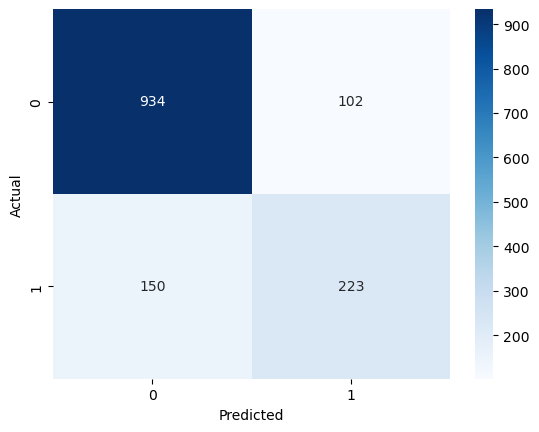

In [160]:
#Task 2.3
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#Task 2.4\
Dapat dilihat bahwa model lebih cenderung untuk mengenali tidak churn dengan recall sebesar 90%. Sedangkan terdapat 373 yang seharusnya churn tetapi terdapat 150 yang terdeteksi salah. Dari segi bisnis, kesalahan ini dapat membuat kerugian bisnis jika tidak dibiarkan pergi tanpa intervensi. Sehingga model baseline perlu ditingkatkan untuk mengurangi kesalahan tersebut.

**Task 3 — Perbandingan Regularization**
1. Latih tiga model: LogisticRegression(penalty='l1', solver='liblinear'), LogisticRegression(penalty='l2'), dan LogisticRegression(penalty=None, solver='lbfgs').
2. Untuk L1 dan L2, gunakan C=0.01, C=0.1, C=1, C=10. Buat tabel perbandingan F1-score pada test set untuk semua nilai C.
3. Pilih satu konfigurasi terbaik. Tampilkan koefisien 10 fitur dengan nilai absolut terbesar.
4. Jelaskan dalam 2-3 kalimat: mengapa L1 menghasilkan koefisien nol pada sebagian fitur, dan apa konsekuensinya untuk interpretasi model?

In [161]:
#Task 3.1
results = []

C_list = [0.01, 0.1, 1, 10]

for c in C_list:
    model_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=1000)
    model_l2 = LogisticRegression(penalty='l2', C=c, max_iter=1000)

    model_l1.fit(X_train, y_train)
    model_l2.fit(X_train, y_train)

    y_pred_l1 = model_l1.predict(X_test)
    y_pred_l2 = model_l2.predict(X_test)

    results.append(['L1', c, f1_score(y_test, y_pred_l1)])
    results.append(['L2', c, f1_score(y_test, y_pred_l2)])

model_none = LogisticRegression(penalty=None, solver='lbfgs')
model_none.fit(X_train, y_train)
y_pred_none = model_none.predict(X_test)
results.append(['None', '-', f1_score(y_test, y_pred_none)])


results_df = pd.DataFrame(results, columns=['Penalty', 'C', 'F1_score'])

results_df



d:\Users\bsi80267\.conda\envs\All-Rounder\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Users\bsi80267\.conda\envs\All-Rounder\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\Users\bsi80267\.conda\envs\All-Rounder\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1

,Penalty,C,F1_score
0,L1,0.01,0.561290
1,L2,0.01,0.625931
2,L1,0.1,0.632801
3,L2,0.1,0.635838
4,L1,1,0.642857
5,L2,1,0.638968
6,L1,10,0.637016
7,L2,10,0.634146
8,None,-,0.634146


In [162]:
best_model = LogisticRegression(penalty='l1', solver='liblinear', C=1, max_iter=1000)
best_model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Koefisien': best_model.coef_[0]
})

coef_df['abs_coef'] = coef_df['Koefisien'].abs()

top_10_features = coef_df.sort_values(
    by='abs_coef',
    ascending=False
).head(10)

print(top_10_features[['Fitur', 'Koefisien']])


                               Fitur  Koefisien
22  OnlineBackup_No internet service  -1.415111
1                             tenure  -1.331636
38                 Contract_Two year  -0.939162
15               InternetService_DSL  -0.631985
3                       TotalCharges   0.628519
36           Contract_Month-to-month   0.486258
20                OnlineSecurity_Yes  -0.449356
11                  PhoneService_Yes  -0.410811
29                   TechSupport_Yes  -0.367522
39               PaperlessBilling_No  -0.334733


d:\Users\bsi80267\.conda\envs\All-Rounder\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Users\bsi80267\.conda\envs\All-Rounder\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


**#Task 3.4**\
Analisis:\
L1 menghasilkan koefisien 0 karena menggunakan nilai absolut, sehingga fitur yang kurang relevan juga diikutkan dalam perhitungan. Namun, karena hal ini membuat fitur yang paling informatif yang digunakan dan berkontribusi dalam prediksi. Fitur yang lain tidak dibuang tetap berkorelasi dengan fitur yang lain.

**Task 4 — ROC Curve dan AUC**
1. Gunakan model terbaik dari Task 3. Hitung predict_proba untuk mendapatkan probabilitas kelas positif.
2. Plot ROC curve dengan label nilai AUC di legend.
3. Bandingkan AUC model terbaik Anda dengan baseline (LogisticRegression default). Berikan kesimpulan 2-3 kalimat.

In [163]:
#Task 1.4
y_prob_best = best_model.predict_proba(X_test)[:, 1]

y_prob_best

array([0.68906892, 0.06265494, 0.00459477, ..., 0.05183407, 0.0132521 ,
       0.50010799], shape=(1409,))

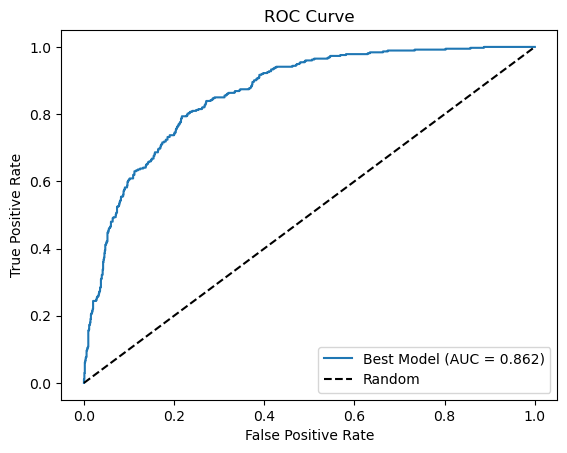

In [164]:
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)
auc_best = roc_auc_score(y_test, y_prob_best)


plt.figure()
plt.plot(fpr_best, tpr_best, label=f'Best Model (AUC = {auc_best:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [165]:
baseline_model = LogisticRegression(max_iter=100).fit(X_train, y_train)

y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]
auc_baseline = roc_auc_score(y_test, y_prob_baseline)

In [167]:
auc_baseline

0.8621489643607607

In [168]:
auc_best

0.862117910710404

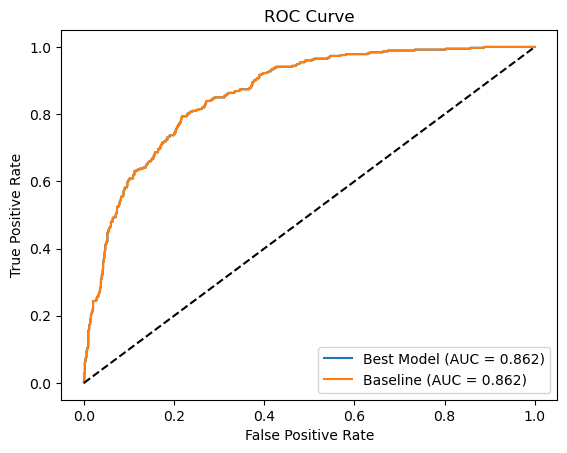

In [166]:
plt.figure()
plt.plot(fpr_best, tpr_best, label=f'Best Model (AUC = {auc_best:.3f})')
plt.plot(fpr_best, tpr_best, label=f'Baseline (AUC = {auc_baseline:.3f})')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**#Task 4.3**\
Baik model terbaik dan model baseline menghasilkan AUC yang identik, masing-masing 0.08621. Selisih sangat kecil sehingga tidak ada perbedaan performa diskriminasi yang berarti. Model L1 dikembangkan untuk lebih mudah diinterpretasikan saja keunggulan yang relevan.